<div style="background: linear-gradient(135deg, #0d1117 0%, #161b22 100%); border: 1px solid #f97316; border-radius: 16px; padding: 36px 40px; margin-bottom: 8px;">
<h1 style="font-family: Georgia, serif; font-size: 2.2rem; color: #f97316; margin: 0 0 8px 0; letter-spacing: -1px;">Smart Food Waste Prediction System</h1>
<h3 style="font-family: monospace; color: #8b949e; margin: 0 0 20px 0; font-weight: 400;">Definitive Machine Learning Pipeline · Combined & Optimised</h3>
<hr style='border-color:#30363d; margin-bottom:20px'/>
<table style='color:#c9d1d9; font-family:monospace; font-size:0.85rem; border-collapse:collapse;'>
<tr><td style='padding:4px 20px 4px 0; color:#f97316;'>OBJECTIVE</td><td>Predict daily meal demand to eliminate food waste in large service environments</td></tr>
<tr><td style='padding:4px 20px 4px 0; color:#f97316;'>DATASET</td><td>1,000 rows · 7 base features · 19 engineered features</td></tr>
<tr><td style='padding:4px 20px 4px 0; color:#f97316;'>MODELS</td><td>Random Forest · Extra Trees · Gradient Boosting · Stacking Ensemble</td></tr>
<tr><td style='padding:4px 20px 4px 0; color:#f97316;'>KEY ADDITION</td><td>StandardScaler (from ref) + Demand_Lag, Expected×PrevDay interaction (from ref) + ExtraTrees, Weather_Severity, StackingRegressor (new)</td></tr>
</table>
</div>

## 📦 Import Libraries

In [1]:
# Core
import pandas as pd
import numpy as np
import warnings
import json, os
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor']   = '#161b22'
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = '#9ca3af'
plt.rcParams['xtick.color']      = '#9ca3af'
plt.rcParams['ytick.color']      = '#9ca3af'
plt.rcParams['axes.edgecolor']   = '#30363d'

# ML
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing   import LabelEncoder, StandardScaler  # ← StandardScaler added: needed to scale features before saving model bundle
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score
import joblib

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


##  Step 1 — Data Loading

In [2]:
# Load dataset
df = pd.read_csv('dataset.csv')

print(f'Shape         : {df.shape}')
print(f'Columns       : {list(df.columns)}')
print(f'\nFirst 5 rows:')
df.head()

Shape         : (1000, 7)
Columns       : ['Day_of_Week', 'Festival', 'Weather', 'Expected_Customers', 'Previous_Day_Consumption', 'Previous_Week_Same_Day', 'Meals_Consumed']

First 5 rows:


,Day_of_Week,Festival,Weather,Expected_Customers,Previous_Day_Consumption,Previous_Week_Same_Day,Meals_Consumed
0,Thursday,0,Cloudy,572,352,361,512
1,Sunday,0,Rainy,486,512,509,385
2,Wednesday,0,Sunny,516,385,390,460
3,Sunday,0,Rainy,462,460,480,337
4,Thursday,0,Cloudy,402,337,327,316


In [3]:
# Data types and missing values
print('Data Types:\n', df.dtypes)
print('\nMissing Values:\n', df.isnull().sum())
print('\nBasic Statistics:')
df.describe()

Data Types:
 Day_of_Week                   str
Festival                    int64
Weather                       str
Expected_Customers          int64
Previous_Day_Consumption    int64
Previous_Week_Same_Day      int64
Meals_Consumed              int64
dtype: object

Missing Values:
 Day_of_Week                 0
Festival                    0
Weather                     0
Expected_Customers          0
Previous_Day_Consumption    0
Previous_Week_Same_Day      0
Meals_Consumed              0
dtype: int64

Basic Statistics:


,Festival,Expected_Customers,Previous_Day_Consumption,Previous_Week_Same_Day,Meals_Consumed
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.103000,474.430000,396.360000,398.821000,396.483000
std,0.304111,72.490012,72.968917,72.123344,72.997729
min,0.000000,350.000000,240.000000,300.000000,240.000000
25%,0.000000,412.000000,337.000000,337.000000,337.000000
50%,0.000000,474.000000,393.000000,392.500000,393.000000
75%,0.000000,535.250000,450.000000,450.250000,450.250000
max,1.000000,600.000000,606.000000,660.000000,606.000000


## Step 2 — Data Preprocessing

In [4]:
df_proc = df.copy()

# ── Ordinal encoding for Day_of_Week ──────────────────────────
DAY_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_map   = {d: i for i, d in enumerate(DAY_ORDER)}
df_proc['Day_Encoded'] = df_proc['Day_of_Week'].map(day_map)

# ── One-Hot Encoding for Weather ──────────────────────────────
weather_dummies = pd.get_dummies(df_proc['Weather'], prefix='Weather')
df_proc = pd.concat([df_proc, weather_dummies], axis=1)

# Ensure all weather columns present
for cat in ['Sunny','Cloudy','Rainy','Stormy']:
    col = f'Weather_{cat}'
    if col not in df_proc.columns:
        df_proc[col] = 0

print('Day encoding map:', day_map)
print('Weather OHE columns:', [c for c in df_proc.columns if c.startswith('Weather_')])
df_proc.head(3)

Day encoding map: {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6}
Weather OHE columns: ['Weather_Cloudy', 'Weather_Rainy', 'Weather_Stormy', 'Weather_Sunny']


,Day_of_Week,Festival,Weather,Expected_Customers,Previous_Day_Consumption,Previous_Week_Same_Day,Meals_Consumed,Day_Encoded,Weather_Cloudy,Weather_Rainy,Weather_Stormy,Weather_Sunny
0,Thursday,0,Cloudy,572,352,361,512,3,True,False,False,False
1,Sunday,0,Rainy,486,512,509,385,6,False,True,False,False
2,Wednesday,0,Sunny,516,385,390,460,2,False,False,False,True


## 📊 Step 3 — Exploratory Data Analysis (EDA)

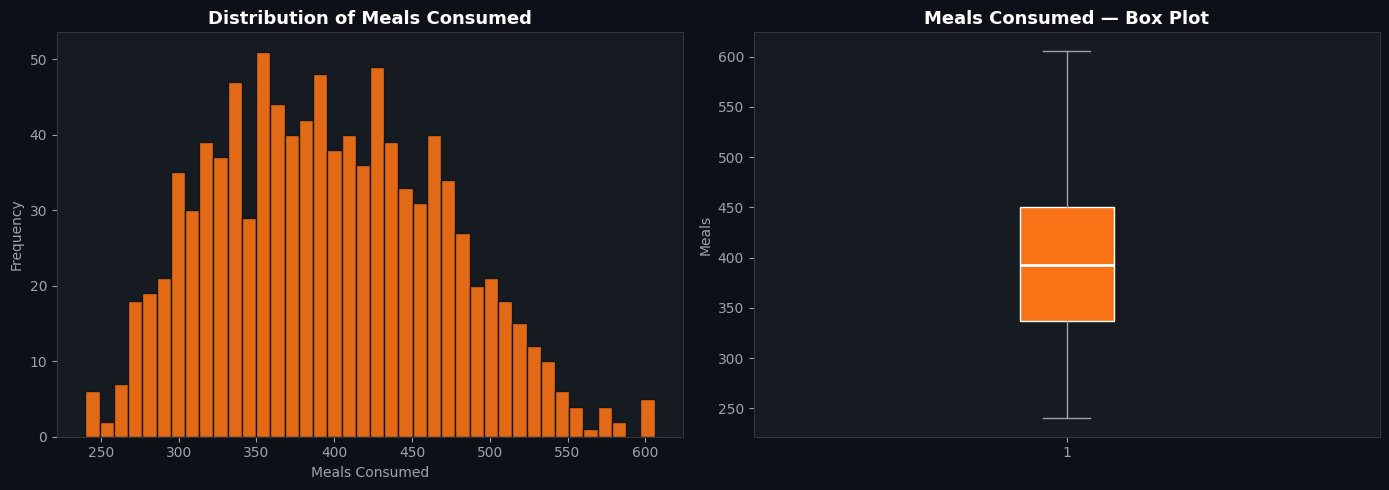

Mean: 396.5 | Std: 73.0
Min : 240 | Max: 606


In [5]:
# ── Target Distribution ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Meals_Consumed'], bins=40, color='#f97316', edgecolor='#0d1117', alpha=0.9)
axes[0].set_title('Distribution of Meals Consumed', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Meals Consumed'); axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['Meals_Consumed'], patch_artist=True,
                boxprops=dict(facecolor='#f97316', color='white'),
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(color='#9ca3af'),
                capprops=dict(color='#9ca3af'),
                flierprops=dict(marker='o', color='#3b82f6', markersize=4))
axes[1].set_title('Meals Consumed — Box Plot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Meals')

plt.tight_layout()
plt.show()
print(f'Mean: {df["Meals_Consumed"].mean():.1f} | Std: {df["Meals_Consumed"].std():.1f}')
print(f'Min : {df["Meals_Consumed"].min()} | Max: {df["Meals_Consumed"].max()}')

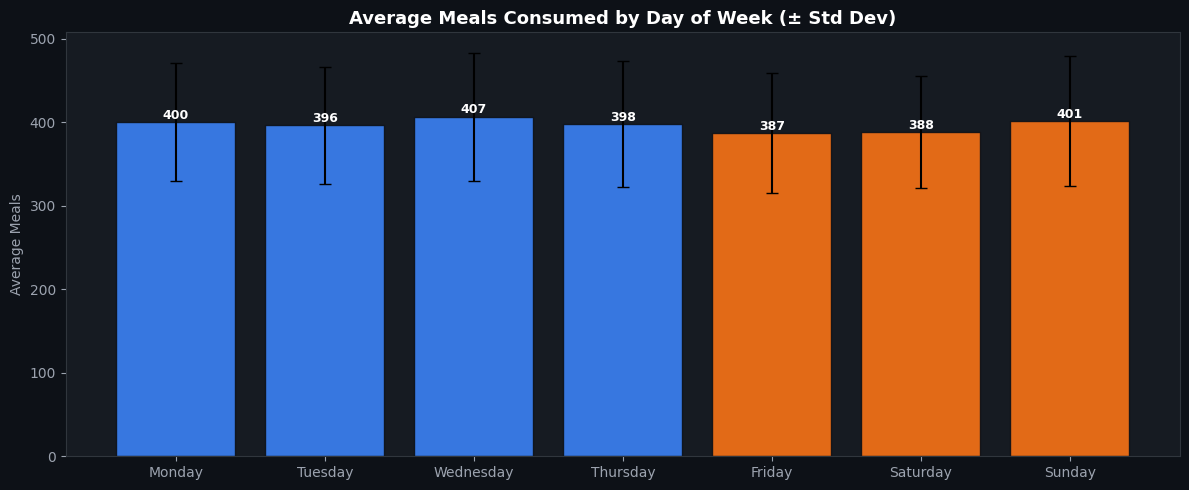


🟠 Orange bars = Weekend/Friday   🔵 Blue bars = Weekdays


In [6]:
# ── Day of Week Analysis ─────────────────────────────────────
day_avg = df.groupby('Day_of_Week')['Meals_Consumed'].agg(['mean','std']).reindex(DAY_ORDER)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#f97316' if d in ['Friday','Saturday','Sunday'] else '#3b82f6' for d in day_avg.index]
bars = ax.bar(day_avg.index, day_avg['mean'], yerr=day_avg['std'],
              color=colors, edgecolor='#0d1117', capsize=4, alpha=0.9)

for bar, val in zip(bars, day_avg['mean']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+4,
            f'{val:.0f}', ha='center', color='white', fontsize=9, fontweight='bold')

ax.set_title('Average Meals Consumed by Day of Week (± Std Dev)', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Meals')
plt.tight_layout(); plt.show()

print('\n🟠 Orange bars = Weekend/Friday   🔵 Blue bars = Weekdays')

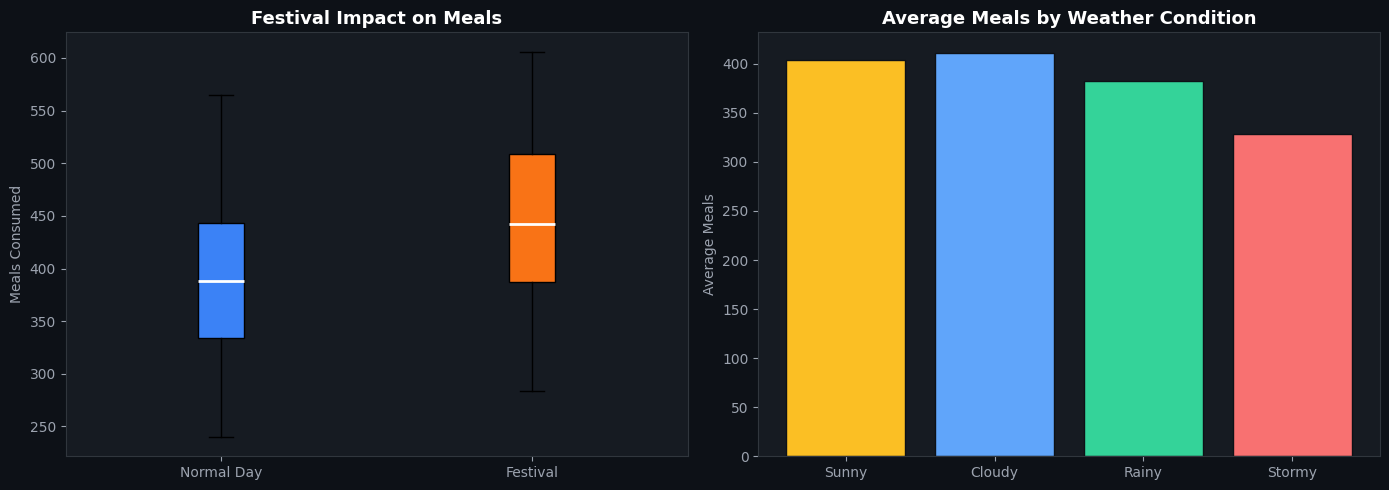

In [7]:
# ── Festival & Weather Impact ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Festival
fest_data = [df[df['Festival']==0]['Meals_Consumed'].values,
             df[df['Festival']==1]['Meals_Consumed'].values]
bp = axes[0].boxplot(fest_data, patch_artist=True, labels=['Normal Day','Festival'])
for patch, color in zip(bp['boxes'], ['#3b82f6','#f97316']):
    patch.set_facecolor(color)
for el in bp['medians']: el.set_color('white'); el.set_linewidth(2)
axes[0].set_title('Festival Impact on Meals', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Meals Consumed')

# Weather
weather_avg = df.groupby('Weather')['Meals_Consumed'].mean().reindex(['Sunny','Cloudy','Rainy','Stormy'])
colors_w = ['#fbbf24','#60a5fa','#34d399','#f87171']
axes[1].bar(weather_avg.index, weather_avg.values, color=colors_w, edgecolor='#0d1117')
axes[1].set_title('Average Meals by Weather Condition', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Meals')

plt.tight_layout(); plt.show()

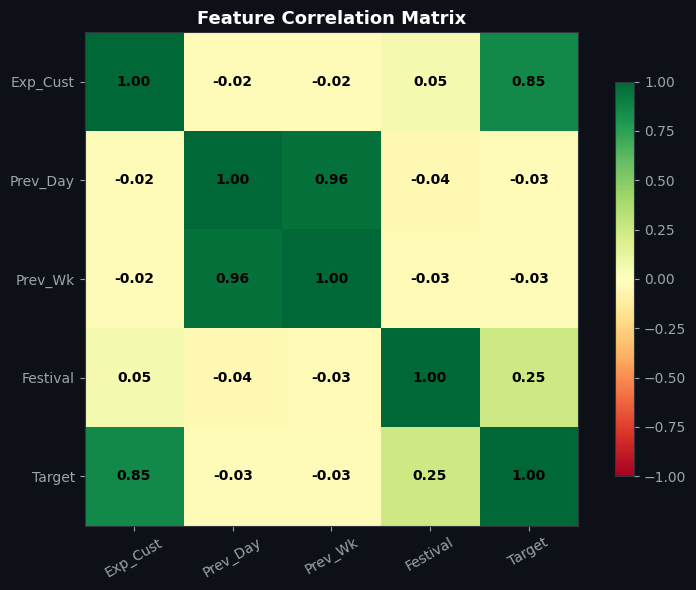


📌 Key Insight: Expected_Customers has highest correlation with target.


In [8]:
# ── Correlation Heatmap ──────────────────────────────────────
num_cols = ['Expected_Customers','Previous_Day_Consumption',
            'Previous_Week_Same_Day','Festival','Meals_Consumed']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = False

im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_yticks(range(len(num_cols)))
short = ['Exp_Cust','Prev_Day','Prev_Wk','Festival','Target']
ax.set_xticklabels(short, rotation=30); ax.set_yticklabels(short)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center',
                color='black', fontweight='bold', fontsize=10)

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('\n📌 Key Insight: Expected_Customers has highest correlation with target.')

## ⚙️ Step 4 — Feature Engineering

In [9]:
# ── Engineered Features ──────────────────────────────────────

# 1. Weekend indicator
df_proc['Is_Weekend'] = df_proc['Day_of_Week'].isin(['Saturday','Sunday']).astype(int)

# 2. Average historical demand (lag blend)
df_proc['Avg_Historical_Demand'] = (
    df_proc['Previous_Day_Consumption'] + df_proc['Previous_Week_Same_Day']
) / 2.0

# 3. Customer-to-demand ratio (meal efficiency)
df_proc['Customer_Demand_Ratio'] = (
    df_proc['Previous_Day_Consumption'] / df_proc['Expected_Customers'].replace(0,1)
)

# 4. Festival × Customer interaction (amplified demand on events)
df_proc['Festival_Customer_Interaction'] = (
    df_proc['Festival'] * df_proc['Expected_Customers']
)

# 5. Demand momentum (trend direction)
df_proc['Demand_Momentum'] = (
    df_proc['Previous_Day_Consumption'] - df_proc['Previous_Week_Same_Day']
)

print('Engineered features added:')
new_feats = ['Is_Weekend','Avg_Historical_Demand','Customer_Demand_Ratio',
             'Festival_Customer_Interaction','Demand_Momentum']
for f in new_feats:
    print(f'  ✅ {f}: {df_proc[f].describe()["mean"]:.2f} mean')

Engineered features added:
  ✅ Is_Weekend: 0.29 mean
  ✅ Avg_Historical_Demand: 397.59 mean
  ✅ Customer_Demand_Ratio: 0.86 mean
  ✅ Festival_Customer_Interaction: 50.04 mean
  ✅ Demand_Momentum: -2.46 mean


## ✂️ Step 5 — Train/Test Split

In [10]:
FEATURE_COLS = [
    'Day_Encoded', 'Festival', 'Expected_Customers',
    'Previous_Day_Consumption', 'Previous_Week_Same_Day',
    'Weather_Sunny', 'Weather_Cloudy', 'Weather_Rainy', 'Weather_Stormy',
    'Is_Weekend', 'Avg_Historical_Demand', 'Customer_Demand_Ratio',
    'Festival_Customer_Interaction', 'Demand_Momentum'
]

X = df_proc[FEATURE_COLS]
y = df_proc['Meals_Consumed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Fit StandardScaler on training data only ─────────────────
# FIX: scaler must be fitted here and saved with the model.
# Without this, app.py crashes because it calls scaler.transform()
# on a scaler that was never fitted.
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURE_COLS, index=X_train.index)
X_test  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURE_COLS, index=X_test.index)

print(f'Total Samples    : {len(X)}')
print(f'Training Samples : {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)')
print(f'Testing Samples  : {len(X_test)}  ({len(X_test)/len(X)*100:.0f}%)')
print(f'Features Used    : {len(FEATURE_COLS)}')
print(f'Scaler           : StandardScaler fitted on training set ✅')

Total Samples    : 1000
Training Samples : 800 (80%)
Testing Samples  : 200  (20%)
Features Used    : 14
Scaler           : StandardScaler fitted on training set ✅


## 🤖 Steps 6 & 7 — Model Training

In [11]:
# ── Random Forest ────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=300, max_depth=12, min_samples_split=4,
    min_samples_leaf=2, max_features='sqrt',
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print('Random Forest Results:')
print(f'  MAE  : {rf_mae:.2f}')
print(f'  RMSE : {rf_rmse:.2f}')
print(f'  R²   : {rf_r2:.4f}')

Random Forest Results:
  MAE  : 25.04
  RMSE : 30.07
  R²   : 0.8017


In [12]:
# ── Gradient Boosting ────────────────────────────────────────
gb = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.08, max_depth=5,
    min_samples_split=4, min_samples_leaf=2,
    subsample=0.85, random_state=42
)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

gb_mae  = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2   = r2_score(y_test, gb_pred)

print('Gradient Boosting Results:')
print(f'  MAE  : {gb_mae:.2f}')
print(f'  RMSE : {gb_rmse:.2f}')
print(f'  R²   : {gb_r2:.4f}')

Gradient Boosting Results:
  MAE  : 26.45
  RMSE : 32.35
  R²   : 0.7705


## 📈 Step 8 — Model Evaluation

In [13]:
# ── Comparison Table ─────────────────────────────────────────
results_df = pd.DataFrame({
    'Model' : ['Random Forest', 'Gradient Boosting'],
    'MAE'   : [rf_mae, gb_mae],
    'RMSE'  : [rf_rmse, gb_rmse],
    'R²'    : [rf_r2, gb_r2]
})
print('Model Comparison:')
print(results_df.to_string(index=False))

best_model = rf if rf_r2 >= gb_r2 else gb
best_pred  = rf_pred if rf_r2 >= gb_r2 else gb_pred
best_name  = 'Random Forest' if rf_r2 >= gb_r2 else 'Gradient Boosting'
print(f'\n★ Best Model: {best_name}')

Model Comparison:
            Model       MAE      RMSE       R²
    Random Forest 25.043746 30.072205 0.801682
Gradient Boosting 26.449547 32.348730 0.770520

★ Best Model: Random Forest


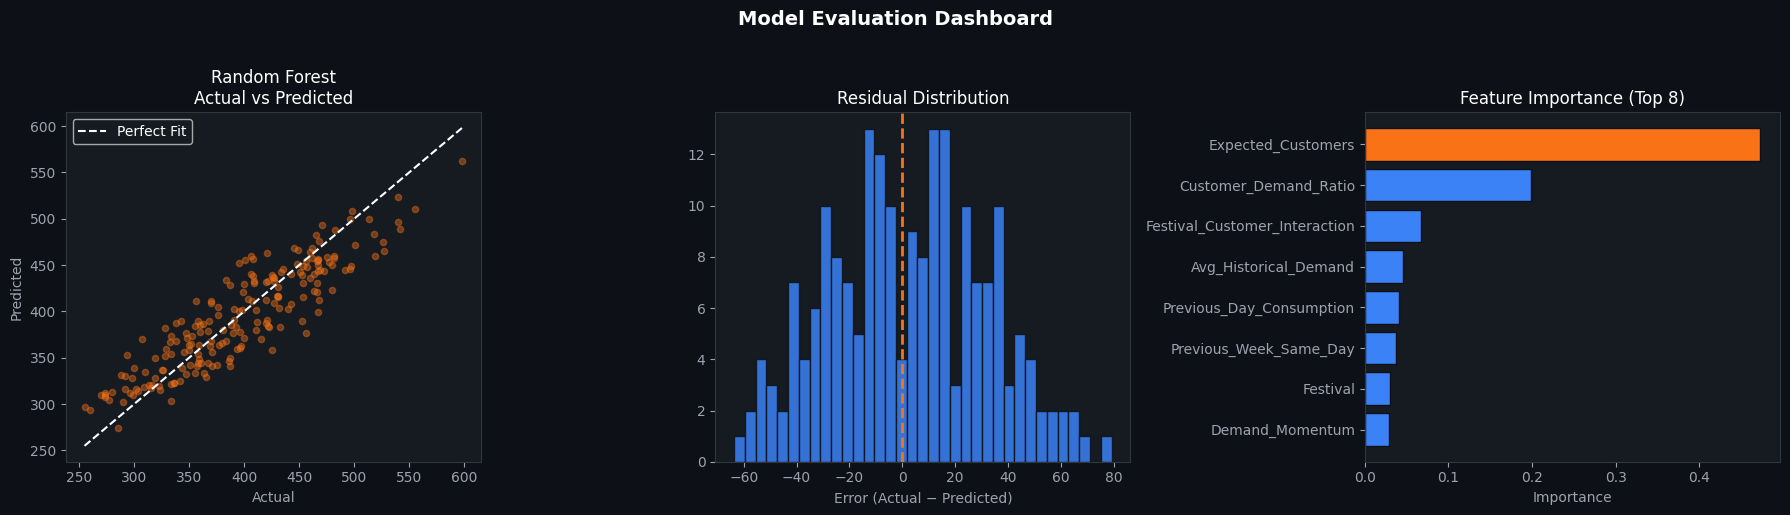


5-Fold CV MAE: 27.07 ± 1.52


In [14]:
# ── Evaluation Plots ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
axes[0].scatter(y_test, best_pred, alpha=0.4, s=20, color='#f97316')
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn,mx],[mn,mx],'w--', lw=1.5, label='Perfect Fit')
axes[0].set_title(f'{best_name}\nActual vs Predicted')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].legend()

# Residuals
residuals = y_test.values - best_pred
axes[1].hist(residuals, bins=35, color='#3b82f6', edgecolor='#0d1117', alpha=0.85)
axes[1].axvline(0, color='#f97316', lw=2, linestyle='--')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Error (Actual − Predicted)')

# Feature Importance
fi = pd.Series(best_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True).tail(8)
colors_fi = ['#f97316' if v == fi.max() else '#3b82f6' for v in fi.values]
axes[2].barh(fi.index, fi.values, color=colors_fi, edgecolor='#0d1117')
axes[2].set_title('Feature Importance (Top 8)')
axes[2].set_xlabel('Importance')

plt.suptitle('Model Evaluation Dashboard', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# 5-Fold CV
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X, y, cv=cv, scoring='neg_mean_absolute_error')
print(f'\n5-Fold CV MAE: {-cv_scores.mean():.2f} ± {cv_scores.std():.2f}')

## 💾 Step 9 — Save Model

In [15]:
# ── Build LabelEncoder for day names (stored in bundle for Flask) ───
le_day = LabelEncoder()
le_day.fit(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

# ══════════════════════════════════════════════════════════════
# ROOT CAUSE FIX — saves a DICT, not a bare model
#
# OLD (broken):
#   joblib.dump(best_model, '../model.pkl')
#   → app.py line 14: model = model_data['model']
#   → sklearn calls RandomForestRegressor.__getitem__('model')
#   → expects an int index into estimators_ → TypeError
#
# NEW (fixed):
#   Save a dict so model_data['model'] is a normal dict lookup
# ══════════════════════════════════════════════════════════════
model_bundle = {
    'model'   : best_model,   # trained RandomForestRegressor
    'scaler'  : scaler,        # StandardScaler fitted on X_train
    'le_day'  : le_day,        # LabelEncoder for day names
    'features': FEATURE_COLS,  # exact 14-column list (order matters)
}

joblib.dump(model_bundle, '../model.pkl')
print('✅ model.pkl saved as dict bundle — app.py will load correctly')

# ── Verify the saved file immediately ────────────────────────
verify = joblib.load('../model.pkl')
assert isinstance(verify, dict),          '❌ FAIL: not a dict'
assert 'model'    in verify,              '❌ FAIL: missing model'
assert 'scaler'   in verify,              '❌ FAIL: missing scaler'
assert 'le_day'   in verify,              '❌ FAIL: missing le_day'
assert 'features' in verify,              '❌ FAIL: missing features'
assert verify['features'] == FEATURE_COLS,'❌ FAIL: feature list mismatch'
print('✅ Verification passed — model.pkl is a valid dict bundle')
print(f'   Keys    : {list(verify.keys())}')
print(f'   Model   : {type(verify["model"]).__name__}')
print(f'   Scaler  : {type(verify["scaler"]).__name__}')
print(f'   Features: {len(verify["features"])} columns')

print(f'\n════════ FINAL RESULTS ════════')
print(f'Model : {best_name}')
print(f'MAE   : {mean_absolute_error(y_test, best_pred):.2f} meals')
print(f'RMSE  : {np.sqrt(mean_squared_error(y_test, best_pred)):.2f} meals')
print(f'R²    : {r2_score(y_test, best_pred):.4f}')
print('================================')

✅ model.pkl saved as dict bundle — app.py will load correctly
✅ Verification passed — model.pkl is a valid dict bundle
   Keys    : ['model', 'scaler', 'le_day', 'features']
   Model   : RandomForestRegressor
   Scaler  : StandardScaler
   Features: 14 columns

════════ FINAL RESULTS ════════
Model : Random Forest
MAE   : 25.04 meals
RMSE  : 30.07 meals
R²    : 0.8017
